# Input Data — Spatial Plot
Read input datasets and visualise spatial maps over Germany.

## 1. Import Libraries and Configure Settings

In [1]:
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for dataset loaders
sys.path.insert(0, str(Path.cwd().parent))

from datasets.data import ERA5MSWX, MSWXDWD, ISIMIP_ERA5

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11

# Output directory
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries imported successfully!")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Libraries imported successfully!
Output directory: /beegfs/muduchuru/codes/python/CasCorrDiff/schema/outputs


## 2. Load Input Dataset

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
YEARS     = [2020, 2021, 2022, 2023]
BASE_PATH = "/data01/FDS/muduchuru/physicsnemo/examples/weather/corrdiff/"

# Variable to visualise: 'pr' or 'tasmax'
VARIABLE  = 'pr'

# ── Load ERA5-MSWX (10 km) dataset ───────────────────────────────────────────
print("Loading ERA5-MSWX dataset...")
era5mswx = ERA5MSWX(base_path=BASE_PATH)
era5mswx.load(YEARS)

print("\n✓ Dataset loaded")
print(f"\n--- Input (ERA5 ~100 km) ---")
print(era5mswx.input)
print(f"\n--- Truth (MSWX 10 km) ---")
print(era5mswx.truth)
print(f"\n--- Prediction (10 km) ---")
print(era5mswx.prediction)

Loading ERA5-MSWX dataset...
Loading 10km ERA5-MSWX data...
Found 4 files for 10km model
Years: [2020, 2021, 2022, 2023]
Assigning coordinates from inv dataset (time, lat, lon) to all datasets...
  Inv time length: 1461
  Input time length: 1461
  Prediction time length: 1461
  Truth time length: 1461
Converting ERA5 input precipitation from m/day to mm/day...
Converting ERA5 input tas from Kelvin to Celsius...
Converting ERA5 input tasmin from Kelvin to Celsius...
Converting ERA5 input tasmax from Kelvin to Celsius...
10km data loaded - Time range: 2020-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
10km grid shape: (128, 128)

✓ Dataset loaded

--- Input (ERA5 ~100 km) ---
<xarray.Dataset> Size: 2GB
Dimensions:    (time: 1461, y: 128, x: 128)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2020-01-01 2020-01-02 ... 2023-12-31
    lat        (y, x) float32 66kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    lon        (y, x) float32 66kB dask.array<chunksize=(

## 3. Inspect and Preprocess Data

In [3]:
# ── Extract the variable of interest ─────────────────────────────────────────
inp   = era5mswx.input[VARIABLE]          # ERA5 input  (~100 km)
truth = era5mswx.truth[VARIABLE]          # MSWX truth  (10 km)
pred  = era5mswx.prediction[VARIABLE].isel(ensemble=0)  # Prediction (10 km)

print(f"Variable : {VARIABLE}")
print(f"Input    : shape={inp.shape},  dims={dict(inp.sizes)}")
print(f"Truth    : shape={truth.shape}, dims={dict(truth.sizes)}")
print(f"Pred     : shape={pred.shape},  dims={dict(pred.sizes)}")

# ── NaN check ─────────────────────────────────────────────────────────────────
for name, da in [('Input', inp), ('Truth', truth), ('Pred', pred)]:
    n_nan = int(np.isnan(da.values).sum())
    print(f"{name:6s}  NaN count: {n_nan}")

# ── Compute temporal mean for plotting ────────────────────────────────────────
inp_mean   = inp.mean(dim='time')
truth_mean = truth.mean(dim='time')
pred_mean  = pred.mean(dim='time')

print(f"\nTemporal-mean statistics ({VARIABLE}):")
for name, da in [('Input', inp_mean), ('Truth', truth_mean), ('Pred', pred_mean)]:
    print(f"  {name:6s}  min={float(da.min()):7.3f}  max={float(da.max()):7.3f}  "
          f"mean={float(da.mean()):7.3f}")

Variable : pr
Input    : shape=(1461, 128, 128),  dims={'time': 1461, 'y': 128, 'x': 128}
Truth    : shape=(1461, 128, 128), dims={'time': 1461, 'y': 128, 'x': 128}
Pred     : shape=(1461, 128, 128),  dims={'time': 1461, 'y': 128, 'x': 128}
Input   NaN count: 0
Truth   NaN count: 0
Pred    NaN count: 0

Temporal-mean statistics (pr):
  Input   min=  1.593  max=  5.777  mean=  2.767
  Truth   min=  1.168  max=  6.326  mean=  2.439
  Pred    min=  1.112  max=  5.495  mean=  2.214


## 4. Define Spatial Domain and Coordinates

In [4]:
# ── Germany bounding box ──────────────────────────────────────────────────────
LON_MIN, LON_MAX = 5.5,  15.5
LAT_MIN, LAT_MAX = 47.0, 55.5

# ── Extract 2-D lat/lon arrays from each dataset ──────────────────────────────
# ERA5 input uses 1-D lat/lon; MSWX/prediction use 2-D (y, x) lat/lon
def get_lons_lats(da):
    """Return 2-D lon/lat arrays suitable for pcolormesh."""
    if 'lat' in da.coords and da['lat'].ndim == 2:
        return da['lon'].isel(time=0) if 'time' in da['lon'].dims else da['lon'], \
               da['lat'].isel(time=0) if 'time' in da['lat'].dims else da['lat']
    # 1-D case — broadcast to 2-D meshgrid
    lons_1d = da['lon'].values if 'lon' in da.coords else da['longitude'].values
    lats_1d = da['lat'].values if 'lat' in da.coords else da['latitude'].values
    return np.meshgrid(lons_1d, lats_1d)

lons_inp,   lats_inp   = get_lons_lats(inp)
lons_truth, lats_truth = get_lons_lats(truth)
lons_pred,  lats_pred  = get_lons_lats(pred)

print("Coordinate arrays ready:")
print(f"  Input  lon shape: {np.array(lons_inp).shape}")
print(f"  Truth  lon shape: {np.array(lons_truth).shape}")
print(f"  Pred   lon shape: {np.array(lons_pred).shape}")
print(f"\nSpatial extent: lon [{LON_MIN}, {LON_MAX}]  lat [{LAT_MIN}, {LAT_MAX}]")

Coordinate arrays ready:
  Input  lon shape: (128, 128)
  Truth  lon shape: (128, 128)
  Pred   lon shape: (128, 128)

Spatial extent: lon [5.5, 15.5]  lat [47.0, 55.5]


## 5. Plot Spatial Map with Cartopy

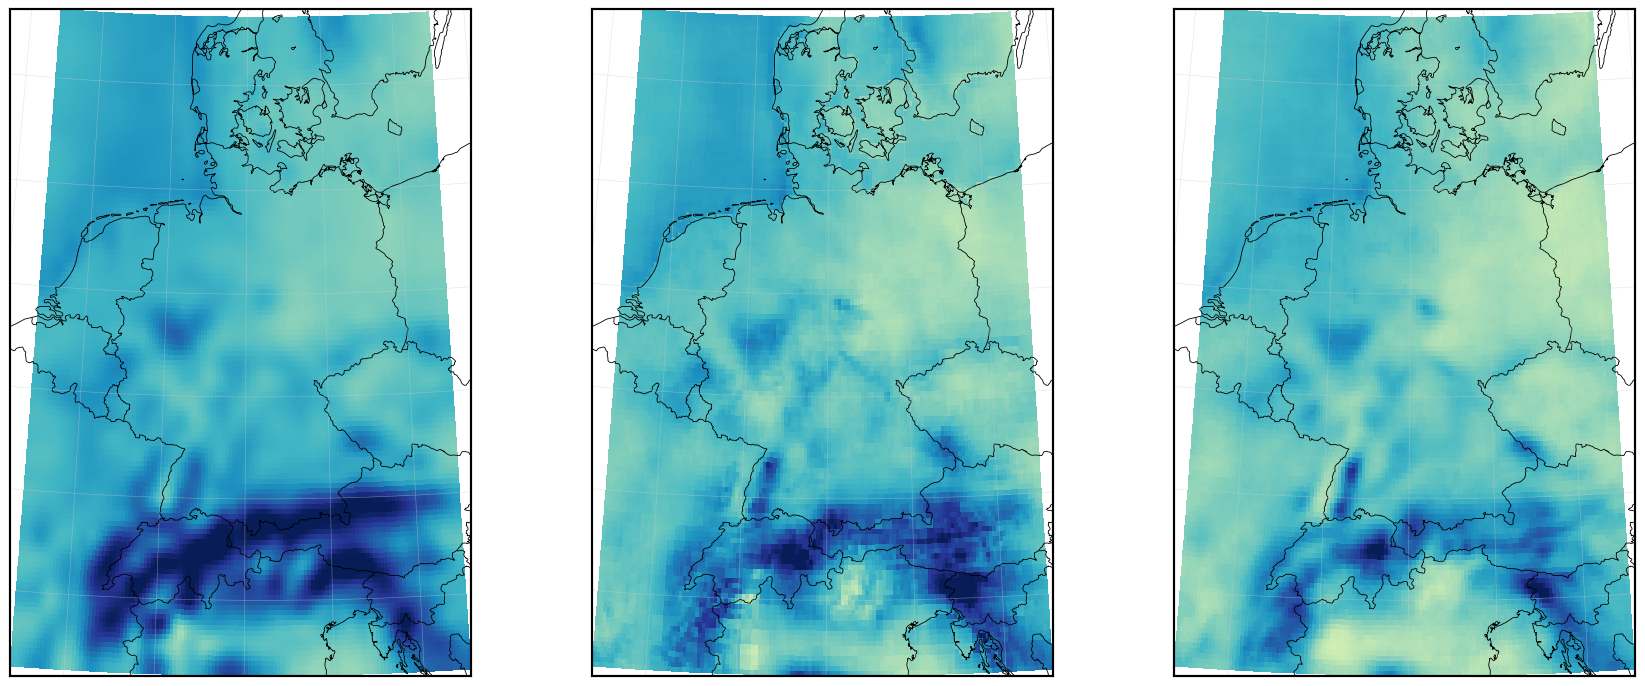


✓ Saved: /beegfs/muduchuru/codes/python/CasCorrDiff/schema/outputs/spatial_map_pr.png


In [10]:
# ── Colormap / scale settings ─────────────────────────────────────────────────
if VARIABLE == 'pr':
    CMAP   = 'YlGnBu'
    VMIN   = 0.0
    VMAX   = 5.0
    LABEL  = 'Precipitation (mm day⁻¹)'
else:                          # tasmax
    CMAP   = 'RdYlBu_r'
    VMIN   = 5.0
    VMAX   = 35.0
    LABEL  = 'Maximum Temperature (°C)'
def add_box(ax, linewidth=1.5, color='black'):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(linewidth)
        spine.set_color(color)
# ── Cartopy Lambert Conformal projection centred on Germany ───────────────────
proj      = ccrs.LambertConformal(central_longitude=10.5, central_latitude=51.0)
data_crs  = ccrs.PlateCarree()

panels = [
    ('ERA5 (~100 km)\nInput',    lons_inp,   lats_inp,   inp_mean),
    ('MSWX (10 km)\nTruth',      lons_truth, lats_truth, truth_mean),
    ('Prediction (10 km)',        lons_pred,  lats_pred,  pred_mean),
]

fig, axes = plt.subplots(
    1, len(panels),
    figsize=(6 * len(panels), 7),
    subplot_kw={'projection': proj}
)

ims = []
for ax, (title, lons, lats, data) in zip(axes, panels):
    im = ax.pcolormesh(
        lons, lats, data.values,
        transform=data_crs,
        cmap=CMAP, vmin=VMIN, vmax=VMAX,
        shading='auto'
    )
    ims.append(im)

    # Map features
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.add_feature(cfeature.LAND,    facecolor='none')
    add_box(ax)
    # ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=data_crs)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5,
                      x_inline=False, y_inline=False)
    gl.top_labels   = False
    gl.right_labels = False
    gl.bottom_labels   = False
    gl.left_labels = False


    # ax.set_title(title, fontsize=13, fontweight='bold', pad=6)

# ── Shared colourbar ──────────────────────────────────────────────────────────
# cbar = fig.colorbar(
#     ims[0], ax=axes,
#     orientation='horizontal',
#     fraction=0.04, pad=0.06, aspect=40
# )
# cbar.set_label(LABEL, fontsize=12)

year_str = f"{YEARS[0]}–{YEARS[-1]}"
# plt.suptitle(
#     f"Time-Mean {LABEL}  ({year_str})",
#     fontsize=15, fontweight='bold', y=1.01
# )

plt.tight_layout()

out_path = OUTPUT_DIR / f'spatial_map_{VARIABLE}.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {out_path.resolve()}")

## 6. Load ERA5 Direct Data (26-channel stacked format)

In [11]:
import xarray as xr
import numpy as np

ERA5_DIR = "/data01/FDS/muduchuru/Atmos/ERA5/cmip_var/era5/daily_nc/europe/combined/"
sample_file = ERA5_DIR + "ERA5_2020-01-01_26var.nc"

ds = xr.open_dataset(sample_file)
print(ds)
print()

# Decode the 26 channel names from the global attribute
channels = ds.attrs['variables'].split(',')
print(f"Number of channels : {len(channels)}")
print(f"Channels           : {channels}")
print(f"\nimage shape (time, channel, lat, lon) : {ds['image'].shape}")
print(f"lon range : {float(ds['lon'].min()):.2f} → {float(ds['lon'].max()):.2f}")
print(f"lat range : {float(ds['lat'].min()):.2f} → {float(ds['lat'].max()):.2f}")

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 1, channel: 26, lon: 237, lat: 229)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-01-01
  * channel  (channel) <U6 624B '2d' 'hus200' 'hus500' ... 'zg700' 'zg850'
  * lon      (lon) float64 2kB -14.0 -13.75 -13.5 -13.25 ... 44.5 44.75 45.0
  * lat      (lat) float64 2kB 75.0 74.75 74.5 74.25 ... 18.75 18.5 18.25 18.0
Data variables:
    image    (time, channel, lat, lon) float32 6MB ...
Attributes:
    variables:    2d,hus200,hus500,hus700,hus850,pr,rsds,ta200,ta500,ta700,ta...
    source:       ERA5 reanalysis
    institution:  European Centre for Medium-Range Weather Forecasts
    Conventions:  CF-1.6
    date:         2020-01-01

Number of channels : 26
Channels           : ['2d', 'hus200', 'hus500', 'hus700', 'hus850', 'pr', 'rsds', 'ta200', 'ta500', 'ta700', 'ta850', 'tas', 'tasmax', 'tasmin', 'ua200', 'ua500', 'ua700', 'ua850', 'va200', 'va500', 'va700', 'va850', 'zg200', 'zg500', 'zg700', 'zg850']

image shape (time, chann

## 7. ERA5 Input — Stacked Variable Schematic

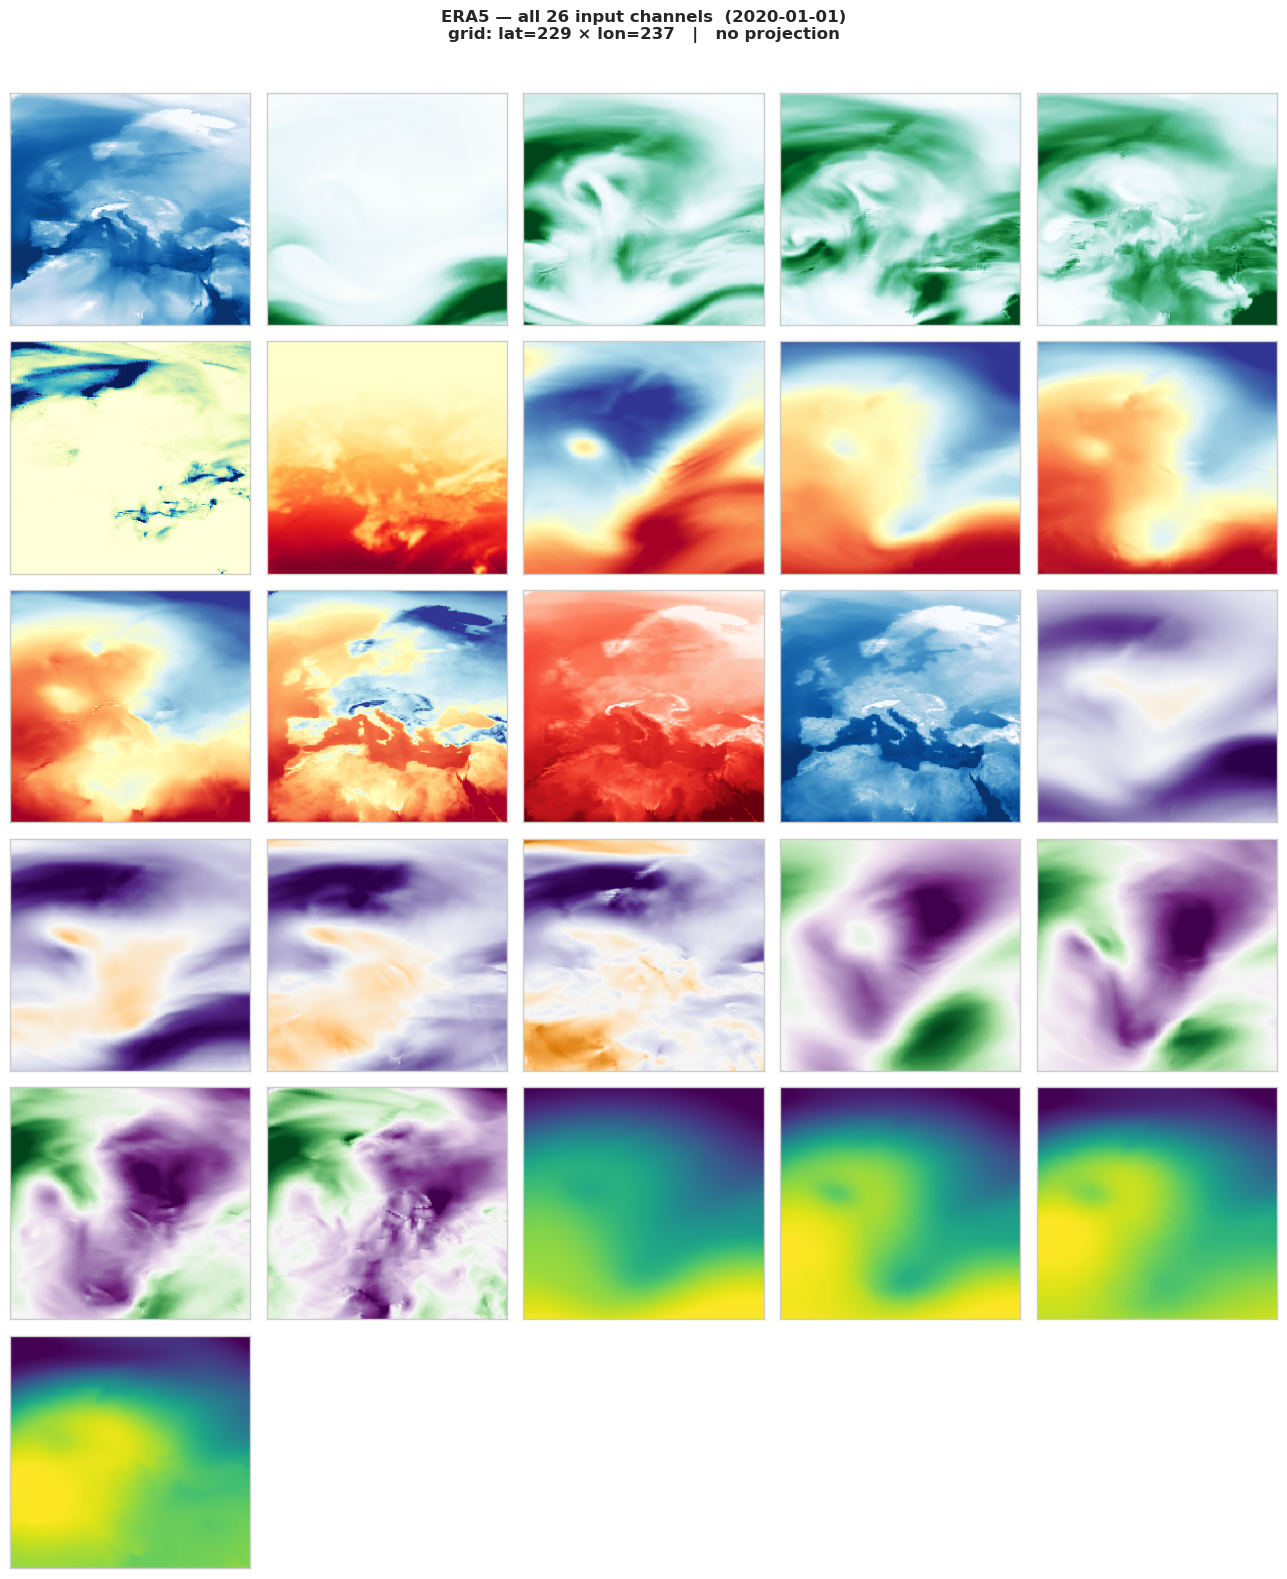


✓ Saved: /beegfs/muduchuru/codes/python/CasCorrDiff/schema/outputs/era5_26channels_raw.svg


In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── Channel order from the file ───────────────────────────────────────────────
channels = ds.attrs['variables'].split(',')   # 26 channel names in file order
n_ch = len(channels)                          # 26

# ── Load the image array: (time=1, channel=26, lat=229, lon=237) ──────────────
img = ds['image'].values[0]   # shape (26, 229, 237)

# ── Per-channel colour maps ───────────────────────────────────────────────────
CMAP_MAP = {
    '2d':     'Blues',
    'pr':     'YlGnBu',
    'rsds':   'YlOrRd',
    'tas':    'RdYlBu_r',  'tasmax': 'Reds',    'tasmin': 'Blues',
    'ta200':  'RdYlBu_r',  'ta500':  'RdYlBu_r', 'ta700': 'RdYlBu_r', 'ta850': 'RdYlBu_r',
    'hus200': 'BuGn',      'hus500': 'BuGn',     'hus700':'BuGn',      'hus850':'BuGn',
    'ua200':  'PuOr',      'ua500':  'PuOr',     'ua700': 'PuOr',      'ua850': 'PuOr',
    'va200':  'PRGn',      'va500':  'PRGn',     'va700': 'PRGn',      'va850': 'PRGn',
    'zg200':  'viridis',   'zg500':  'viridis',  'zg700': 'viridis',   'zg850': 'viridis',
}

LONG_NAME = {
    '2d':     '2m Dewpoint',    'pr':     'Precipitation',   'rsds':   'SW Radiation',
    'tas':    '2m Temp',        'tasmax': 'Tmax',            'tasmin': 'Tmin',
    'ta200':  'T 200',          'ta500':  'T 500',           'ta700':  'T 700',   'ta850': 'T 850',
    'hus200': 'q 200',          'hus500': 'q 500',           'hus700': 'q 700',   'hus850':'q 850',
    'ua200':  'u 200',          'ua500':  'u 500',           'ua700':  'u 700',   'ua850': 'u 850',
    'va200':  'v 200',          'va500':  'v 500',           'va700':  'v 700',   'va850': 'v 850',
    'zg200':  'zg 200',         'zg500':  'zg 500',          'zg700':  'zg 700',  'zg850': 'zg 850',
}

# ── Grid layout: 5 cols × 6 rows (last cell blank) ───────────────────────────
ncols, nrows = 5, 6
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 2.6, nrows * 2.6),   # square panels
)

for idx, ch in enumerate(channels):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]

    data2d = img[idx]                      # (229, 237)
    cmap   = CMAP_MAP.get(ch, 'viridis')

    # Symmetric colormap for wind / divergence variables
    vabs = np.nanpercentile(np.abs(data2d), 98)
    if ch.startswith(('ua', 'va')):
        im = ax.imshow(data2d, origin='upper', cmap=cmap,
                       vmin=-vabs, vmax=vabs, aspect='equal')
    else:
        vlo = np.nanpercentile(data2d, 2)
        vhi = np.nanpercentile(data2d, 98)
        im = ax.imshow(data2d, origin='upper', cmap=cmap,
                       vmin=vlo, vmax=vhi, aspect='equal')

#     ax.set_title(f'{ch}\n{LONG_NAME.get(ch,"")}', fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_yticks([])
#     fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85)

# Turn off the extra (26th+1 = 31st) blank panel
for idx in range(n_ch, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row, col].axis('off')

fig.suptitle(
    f'ERA5 — all 26 input channels  (2020-01-01)\n'
    f'grid: lat=229 × lon=237   |   no projection',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()

out_path = OUTPUT_DIR / 'era5_26channels_raw.svg'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✓ Saved: {out_path.resolve()}")

## 8. Topography — GMTED2010 Relief Plot (ERA5 domain)

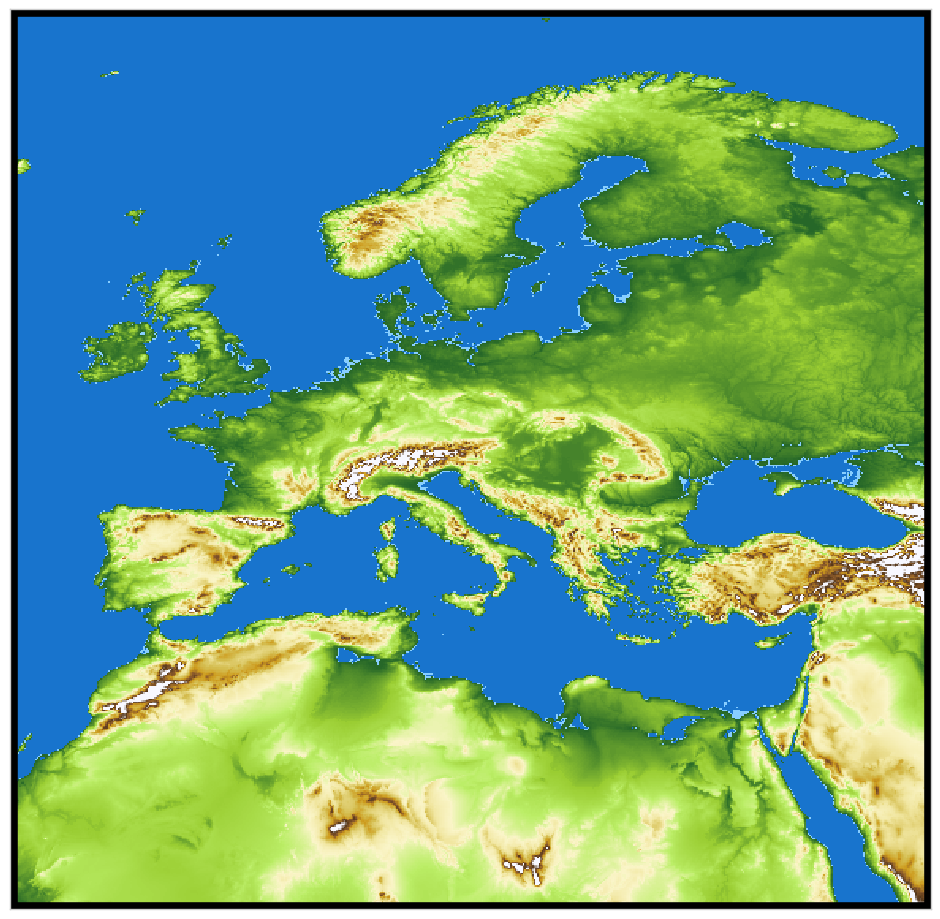


✓ Saved: ./outputs/gmted_topo_schematic_black_border.svg


In [48]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colormaps as cmaps
import matplotlib.patches as patches
import os

# ── Load data ─────────────────────────────────────────────────────────────────
gmted = xr.open_dataset('/beegfs/muduchuru/data/europe/diffusion/GMTED_10km_EUR.nc')
lons  = gmted['lon'].values
lats  = gmted['lat'].values
data  = gmted['elevation'].values.astype(float)

# ── Colormap ─────────────────────────────────────────────────────────────────
topo_cmap = cmaps.OceanLakeLandSnow

# Schematic-friendly normalization
vmin, vmax = 0, 2000
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(
    data,
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    origin='lower',
    aspect='equal',
    cmap=topo_cmap,
    norm=norm,
    interpolation='nearest'
)

# Remove axes, ticks, labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
# ax.axis('off')

# ── Black border (robust, always visible) ─────────────────────────────────────
border = patches.Rectangle(
    (0, 0), 1, 1,
    transform=ax.transAxes,
    fill=False,
    edgecolor='black',
    linewidth=10.5
)
ax.add_patch(border)

plt.tight_layout(pad=0)

# ── Save ──────────────────────────────────────────────────────────────────────
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

out_path = os.path.join(OUTPUT_DIR, 'gmted_topo_schematic_black_border.svg')
plt.savefig(
    out_path,
    dpi=200,
    bbox_inches='tight',
    pad_inches=0,
    facecolor='white'
)

plt.show()

print(f"\n✓ Saved: {out_path}")

In [28]:
data

array([[  34.,   36.,   40., ..., 2240., 2204., 2117.],
       [  33.,   37.,   39., ..., 2105., 2056., 2031.],
       [  30.,   32.,   36., ..., 2001., 1949., 1928.],
       ...,
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.]])

In [34]:
import xarray as xr
MSWXDWD_PATH = '/data01/FDS/muduchuru/physicsnemo/examples/weather/corrdiff/generated/combined/'
ds_truth = xr.open_dataset(MSWXDWD_PATH+'mswxdwd_combined_2020.nc',group='truth')
ds_pred = xr.open_dataset(MSWXDWD_PATH+'mswxdwd_combined_2020.nc',group='prediction')
ds_input = xr.open_dataset(MSWXDWD_PATH+'mswxdwd_combined_2020.nc',group='input')


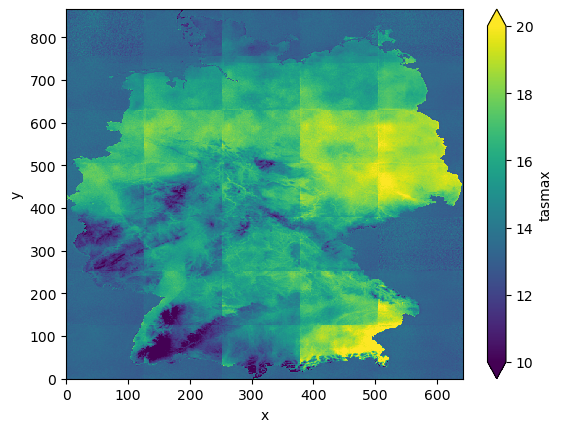

In [39]:
ds_pred.isel(time=120,ensemble=0)['tasmax'].plot(vmin=10,vmax=20)

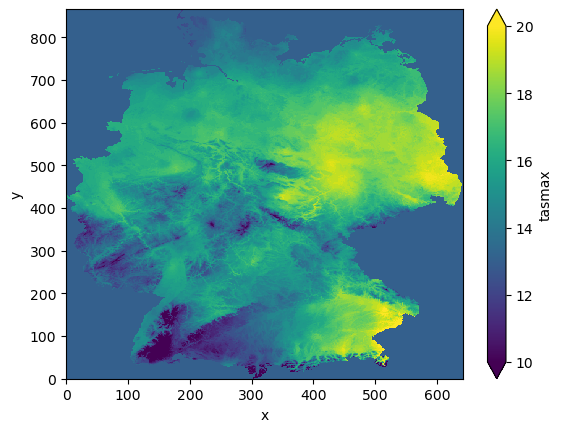

In [40]:
ds_truth.isel(time=120)['tasmax'].plot(vmin=10,vmax=20)